In [1]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
%matplotlib inline

## Άσκηση - Το φαινόμενο της ξαφνικής εισόδου (*sudden input*) σε ΓΧΑ σύστημα

Σε σχετική άσκηση στο Κεφάλαιο 6 είδαμε το φαινόμενο της απότομης εισόδου σε ένα σύστημα **συνεχούς** χρόνου. Το ίδιο ακριβώς συμβαίνει και στον **διακριτό** κόσμο, εκεί που ζουν τα ψηφιακά μας φίλτρα! 🙂

Όταν αναλύουμε ένα Γραμμικό Χρονικά Αμετάβλητο (ΓΧΑ) σύστημα διακριτού χρόνου στο πεδίο της συχνότητας, χρησιμοποιούμε την απόκριση συχνότητας $H(e^{j\omega})$ (τον μετασχ. Fourier διακριτού χρόνου, DTFT, της κρουστικής απόκρισης) και λέμε ότι 

**"αν βάλω στην είσοδο ένα ημίτονο συχνότητας $\omega_0$ (σε rad/δείγμα), στην έξοδο θα πάρω το ίδιο ημίτονο, πολλαπλασιασμένο κατά $|H(e^{j\omega_0})|$ και μετατοπισμένο κατά $\angle H(e^{j\omega_0})$".**

Και πάλι όμως κρύβεται η σιωπηρή παραδοχή ότι το ημίτονο υπάρχει **από πάντα**, δηλ. από $n=-\infty$.

Στην πράξη όμως εμείς **ξεκινάμε** την είσοδο σε κάποιο δείγμα - ας πούμε στο $n=0$. Η απότομη αυτή εφαρμογή διεγείρει, εκτός από τη **μόνιμη** (steady-state) απόκριση, και τη **μεταβατική** απόκριση του συστήματος, η οποία - για ένα ευσταθές σύστημα - σβήνει καθώς το $n$ μεγαλώνει. Έτσι η έξοδος **δεν** ξεκινά κατ' ευθείαν ως το "καθαρό" ημίτονο της μόνιμης κατάστασης. Ας το δούμε!

Ας θεωρήσουμε ένα απλό 1ης τάξης σύστημα διακριτού χρόνου (ένα ψηφιακό χαμηλοπερατό φίλτρο, γνωστό και ως *leaky integrator*), που περιγράφεται από την εξίσωση διαφορών

$$ y[n] = \alpha\, y[n-1] + (1-\alpha)\, x[n], \qquad 0 < \alpha < 1 $$

Με μηδενικές αρχικές συνθήκες ($y[-1]=0$) το σύστημα είναι ΓΧΑ. Βρίσκουμε τη συχνοτική απόκριση:

$$H(e^{j\omega}) = \frac{1-\alpha}{1-\alpha e^{-j\omega}} $$

Για λόγους που δεν είναι τώρα εμφανείς, όσο πιο κοντά στον μοναδιαίο κύκλο ($\alpha \to 1$), τόσο πιο αργά σβήνει! 😉

**Είσοδος που εφαρμόζεται απότομα:** Έστω ότι στο $n=0$ ξεκινάμε ένα συνημίτονο:

$$ x[n] = \cos(\omega_0 n)\, u[n] $$

Το $u[n]$ (μοναδιαία βηματική ακολουθία) είναι αυτό που κάνει την είσοδο *απότομη*: για $n<0$ δεν υπάρχει τίποτα, και στο $n=0$ εμφανίζεται ξαφνικά το ημίτονο.

Αν το ημίτονο υπήρχε από το $-\infty$, η έξοδος θα ήταν **μόνο** η απόκριση σταθερής κατάστασης, την οποία μας δίνει κατ' ευθείαν η συχνοτική απόκριση:

$$ y_{ss}[n] = |H(e^{j\omega_0})| \, \cos\!\big(\omega_0 n + \angle H(e^{j\omega_0})\big) $$

όπου, για το δικό μας σύστημα $H(e^{j\omega})=\dfrac{1-\alpha}{1-\alpha e^{-j\omega}}$,

$$ |H(e^{j\omega_0})| = \frac{1-\alpha}{\sqrt{1 - 2\alpha\cos\omega_0 + \alpha^2}}, \qquad \angle H(e^{j\omega_0}) = -\arctan\!\left(\frac{\alpha\sin\omega_0}{1-\alpha\cos\omega_0}\right) $$

**Η συνολική απόκριση:** Επειδή η είσοδος εφαρμόζεται απότομα, η πλήρης λύση της εξίσωσης διαφορών είναι το άθροισμα της απόκρισης σταθερής κατάστασης **και** της μεταβατικής απόκρισης της μορφής $C\,\alpha^{\,n}$:

$$ y[n] = \underbrace{|H(e^{j\omega_0})|\cos\!\big(\omega_0 n + \angle H(e^{j\omega_0})\big)}_{\text{απόκριση σταθερής κατάσταση } y_{ss}[n]} \; + \; \underbrace{C\,\alpha^{\,n}}_{\text{μεταβατική απόκριση}}, \qquad n \ge 0 $$

Τη σταθερά $C$ τη βρίσκουμε από την αρχική συνθήκη. Από την ίδια την εξίσωση διαφορών, με $y[-1]=0$, το πρώτο δείγμα της εξόδου είναι $y[0] = \alpha\cdot 0 + (1-\alpha)\cos(0) = 1-\alpha$. Απαιτώντας η παραπάνω μορφή να το δίνει στο $n=0$:

$$ y[0] = |H(e^{j\omega_0})|\cos\big(\angle H(e^{j\omega_0})\big) + C = 1-\alpha \;\Rightarrow\; C = (1-\alpha) - \operatorname{Re}\{H(e^{j\omega_0})\} $$

(θυμηθείτε ότι $|H(e^{j\omega_0})|\cos(\angle H(e^{j\omega_0})) = \operatorname{Re}\{H(e^{j\omega_0})\}$). Άρα

\begin{equation}
y[n] = |H(e^{j\omega_0})|\cos\!\big(\omega_0 n + \angle H(e^{j\omega_0})\big) \; + \; \big[(1-\alpha) - \Re\{H(e^{j\omega_0})\}\big]\, \alpha^{\,n}, \qquad n\ge 0
\end{equation}

Η δεύτερη - γεωμετρικά φθίνουσα - συνιστώσα είναι το "τίμημα" της απότομης εισόδου. Σβήνει με σταθερά χρόνου περίπου $\tau \approx 1/(1-\alpha)$ δείγματα και μετά η έξοδος ταυτίζεται με τη μόνιμη κατάσταση.

Ας το επιβεβαιώσουμε αριθμητικά. Εδώ έχουμε ένα ωραίο πλεονέκτημα σε σχέση με την περίπτωση συνεχούς χρόνου (άσκηση Κεφαλαίου 6): η εξίσωση διαφορών **είναι** ήδη το ακριβές σύστημα διακριτού χρόνου, οπότε δεν χρειαζόμαστε καμία προσέγγιση τύπου Euler - απλώς τρέχουμε αναδρομικά τη σχέση

$$ y[n] = \alpha\, y[n-1] + (1-\alpha)\, x[n] $$

Η αναδρομή αυτή περιέχει **αυτόματα** και τη μεταβατική και τη μόνιμη συνιστώσα. Θα τη συγκρίνουμε με (α) τη θεωρητική ολική λύση - εξίσωση $(1)$ - και (β) **μόνο** με τη μόνιμη απόκριση $y_{ss}[n]$, ώστε να δούμε πόσο διαφέρουν στην αρχή.

In [2]:
f0 = 0.05                                # Συχνότητα εισόδου (κύκλοι ανά δείγμα)
w0 = 2*np.pi*f0                          # Κυκλική συχνότητα (rad ανά δείγμα)
alpha = 0.9                              # Τιμή του α

N = 100                                   # Πλήθος δειγμάτων
n = np.arange(0, N)                       # Διάνυσμα δεικτών n = 0,1,2,...

x = np.cos(w0*n)                          # Ξαφνική είσοδος x[n] = cos(w0 n) u[n] (το u[n] υπονοείται: n ξεκινά από 0)

# --- (1) Αναδρομική ("πραγματική") έξοδος: περιέχει μεταβατική + μόνιμη ---
y = np.zeros(N)                           # Δέσμευση μνήμης
y[0] = (1-alpha)*x[0]                     # Πρώτο δείγμα, με y[-1]=0 (ηρεμία)

for k in range(1, N):                     # Υλοποίηση της εξίσωσης διαφορών
    y[k] = alpha*y[k-1] + (1-alpha)*x[k]

# --- Απόκριση συχνότητας στο w0 ---
H = (1-alpha) / (1 - alpha*np.exp(-1j*w0))  # H(e^{jw0})
Hmag = np.abs(H)                            # |H(e^{jw0})|
Hphase = np.angle(H)                        # ∠H(e^{jw0})

# --- (2) Μόνιμη απόκριση (steady-state), σαν να υπήρχε το ημίτονο από πάντα ---
y_ss = Hmag*np.cos(w0*n + Hphase)

# --- (3) Θεωρητική ΟΛΙΚΗ λύση: σταθερής κατάστασης + μεταβατική απόκριση (εξίσωση (1) στην εκφώνηση) ---
C = (1-alpha) - np.real(H)                # C = (1-alpha) - Re{H(e^{jw0})}
y_trans = C*alpha**n                      # Μεταβατική συνιστώσα
y_theory = y_ss + y_trans

Ας τα απεικονίσουμε όλα μαζί.

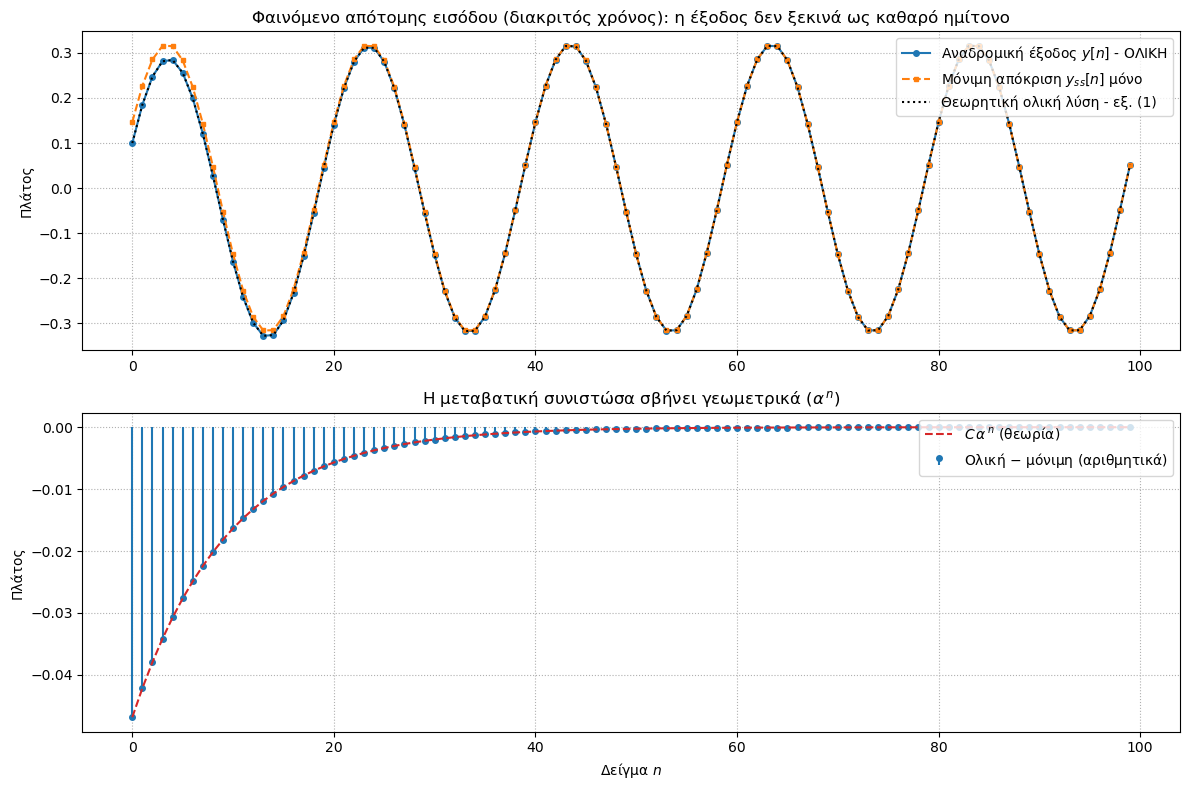

In [3]:
plt.figure(figsize=(12,8))

# Πάνω: αναδρομική έξοδος vs μόνιμη απόκριση
plt.subplot(2,1,1)
plt.plot(n, y, 'o-', markersize=4, label='Αναδρομική έξοδος $y[n]$ - ΟΛΙΚΗ')
plt.plot(n, y_ss, 's--', markersize=3, label='Μόνιμη απόκριση $y_{ss}[n]$ μόνο')
plt.plot(n, y_theory, ':', color='k', label='Θεωρητική ολική λύση - εξ. (1)')
plt.grid(linestyle=':')
plt.title('Φαινόμενο απότομης εισόδου (διακριτός χρόνος): η έξοδος δεν ξεκινά ως καθαρό ημίτονο')
plt.ylabel('Πλάτος')
plt.legend(loc='upper right')

# Κάτω: η μεταβατική συνιστώσα (διαφορά ολικής - μόνιμης)
plt.subplot(2,1,2)
markerline, stemlines, baseline = plt.stem(n, y - y_ss, basefmt=' ', label='Ολική $-$ μόνιμη (αριθμητικά)')
plt.setp(markerline, markersize=4)
plt.plot(n, y_trans, '--', color='tab:red', label='$C\\,\\alpha^{\\,n}$ (θεωρία)')
plt.grid(linestyle=':')
plt.title('Η μεταβατική συνιστώσα σβήνει γεωμετρικά ($\\alpha^{\\,n}$)')
plt.xlabel('Δείγμα $n$')
plt.ylabel('Πλάτος')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Παρατηρήστε δύο πράγματα:

- Στα πρώτα δείγματα ($n$ κοντά στο $0$) η αληθινή έξοδος **αποκλίνει** από τη μόνιμη απόκριση $y_{ss}[n]$. Αυτή η απόκλιση είναι η μεταβατική συνιστώσα - το αποτύπωμα του ότι "ξεκινήσαμε" την είσοδο απότομα.
- Στο κάτω γράφημα, η διαφορά *ολική $-$ μόνιμη* ταυτίζεται **ακριβώς** (μέχρι το σφάλμα της μηχανής, αφού εδώ δεν υπάρχει καμία προσέγγιση διακριτοποίησης!) με τη γεωμετρική ακολουθία $C\,\alpha^{\,n}$ και σβήνει μέσα σε λίγες σταθερές χρόνου $\tau \approx 1/(1-\alpha)$ δείγματα.

---

**Άσκηση.** Το πόσο "εμφανές" και πόσο "μακρύ" είναι το φαινόμενο εξαρτάται από τη θέση του πόλου $\alpha$ (δηλ. πόσο κοντά είναι στον μοναδιαίο κύκλο). Γράψτε κώδικα `Python` που:

(α') Επαναλαμβάνει την προσομοίωση για έναν πόλο **πιο κοντά στον μοναδιαίο κύκλο**, π.χ. $\alpha = 0.97$ (κρατήστε π.χ. $f_0 = 0.05$), και τυπώνει τα αντίστοιχα γραφήματα (ολική έξοδος, μόνιμη, και μεταβατική). Ίσως χρειαστείτε περισσότερα δείγματα $N$ για να προλάβει να σβήσει η μεταβατική.

(β') Στο κάτω γράφημα, σχεδιάστε και την **περιβάλλουσα** $\pm|C|\,\alpha^{\,n}$ της μεταβατικής, για να επιβεβαιώσετε ότι η μεταβατική "χωράει" μέσα σε αυτήν.

*Υπόδειξη:* αρκεί να αλλάξετε τα `alpha` και `N` και να επαναχρησιμοποιήσετε τον κώδικα παραπάνω.

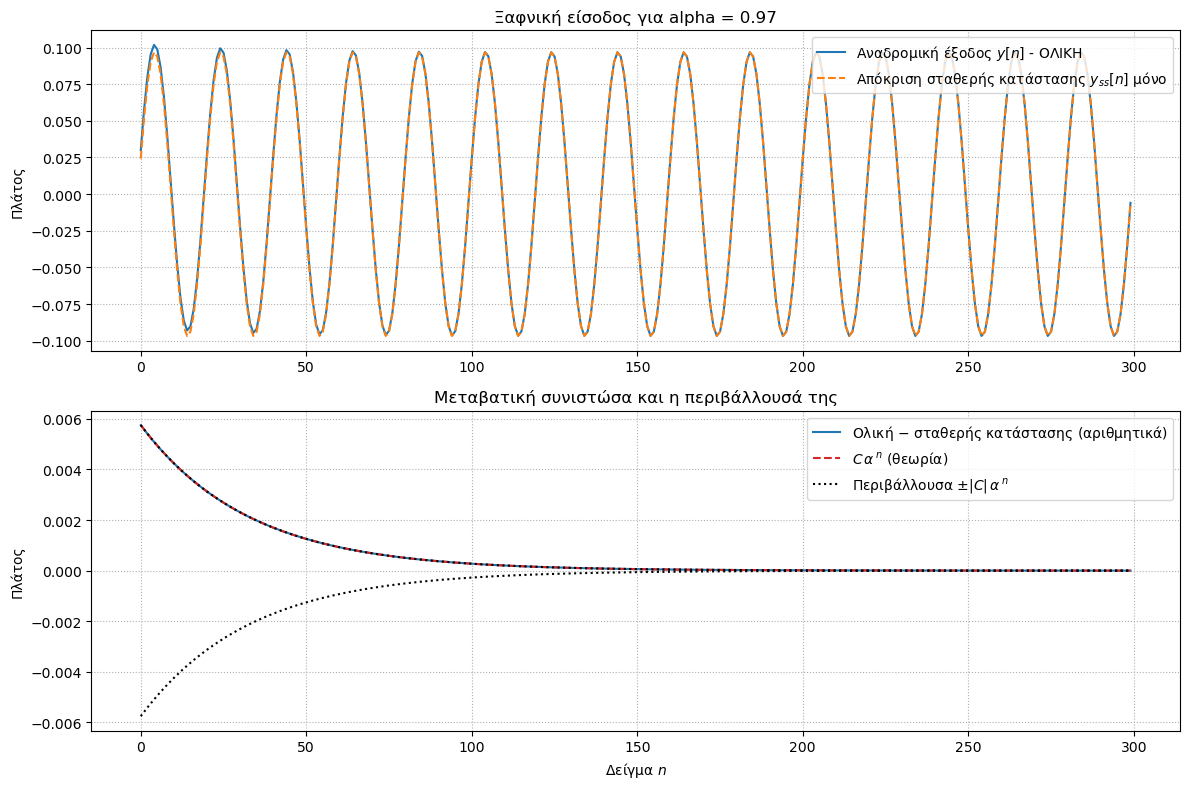

In [4]:
# INSERT CODE HERE

f0 = 0.05
w0 = 2*np.pi*f0
alpha = 0.97                             # Τιμή του α, πιο κοντά στο 1, ώστε να σβήσει πιο αργά η μεταβατική

N = 300                                  # Περισσότερα δείγματα, ώστε να προλάβει να σβήσει η μεταβατική
n = np.arange(0, N)

x = np.cos(w0*n)                         # Ξαφνική είσοδος

# Αναδρομική έξοδος
y = np.zeros(N)
y[0] = (1-alpha)*x[0]
for k in range(1, N):
    y[k] = alpha*y[k-1] + (1-alpha)*x[k]

# Απόκριση συχνότητας, σταθερής κατάστασης και μεταβατική
H = (1-alpha) / (1 - alpha*np.exp(-1j*w0))
y_ss = np.abs(H)*np.cos(w0*n + np.angle(H))
C = (1-alpha) - np.real(H)
y_trans = C*alpha**n

# Γραφήματα
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.plot(n, y, '-', label='Αναδρομική έξοδος $y[n]$ - ΟΛΙΚΗ')
plt.plot(n, y_ss, '--', label='Απόκριση σταθερής κατάστασης $y_{ss}[n]$ μόνο')
plt.grid(linestyle=':')
plt.title(f'Ξαφνική είσοδος για alpha = {alpha}')
plt.ylabel('Πλάτος')
plt.legend(loc='upper right')

plt.subplot(2,1,2)
plt.plot(n, y - y_ss, '-', label='Ολική $-$ σταθερής κατάστασης (αριθμητικά)')
plt.plot(n, y_trans, '--', color='tab:red', label='$C\\,\\alpha^{\\,n}$ (θεωρία)')
plt.plot(n,  np.abs(C)*alpha**n, ':', color='k', label='Περιβάλλουσα $\\pm|C|\\,\\alpha^{\\,n}$')
plt.plot(n, -np.abs(C)*alpha**n, ':', color='k')
plt.grid(linestyle=':')
plt.title('Μεταβατική συνιστώσα και η περιβάλλουσά της')
plt.xlabel('Δείγμα $n$')
plt.ylabel('Πλάτος')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# END OF CODE

Τι παρατηρείτε καθώς η τιμή του $\alpha$ πλησιάζει το $1$ ($\alpha \to 1$); Πώς αλλάζει η διάρκεια της μεταβατικής; Γράψτε την απάντησή σας σε αυτό το κελί:

Όσο $\alpha \to 1$, η μεταβατική απόκριση $\alpha^{\,n}$ σβήνει όλο και **πιο αργά**: η σταθερά χρόνου $\tau \approx 1/(1-\alpha)$ μεγαλώνει, οπότε η μεταβατική απόκριση διαρκεί για πολλά περισσότερα δείγματα και το φαινόμενο της ξαφνικής εισόδου γίνεται πιο εμφανές και πιο μακροχρόνιο. Στο όριο $\alpha = 1$, το σύστημα παύει να είναι (αυστηρά) ευσταθές και η μεταβατική απόκριση δεν σβήνει ποτέ. Σημειώστε ότι ο ρυθμός απόσβεσης καθορίζεται **μόνο** από την τιμή του $\alpha$ και όχι από τη συχνότητα εισόδου $\omega_0$. Η $\omega_0$ επηρεάζει μόνο το πλάτος/φάση της απόκρισης σταθερής κατάστασης και τη σταθερά $C$.

---
---